# Python Warm-Up Exercises
**Data Visualization · scikit-learn ML Workflow**

Each exercise has a `# YOUR CODE HERE` scaffold and a solution cell below it. Try it yourself first!

---

## Setup — Run This First

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load a built-in sklearn dataset (no file needed)
data = load_diabetes(as_frame=True)
df = data.frame

print(df.shape)
df.head()

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


---
# Part A — Data Visualization

## A1 · Distribution of the Target Variable

Plot the distribution of `target` (disease progression score).
- Create a figure with **2 subplots side by side**
- Left: histogram with KDE curve (`sns.histplot` with `kde=True`)
- Right: boxplot (`sns.boxplot`)
- Add titles and call `plt.tight_layout()`

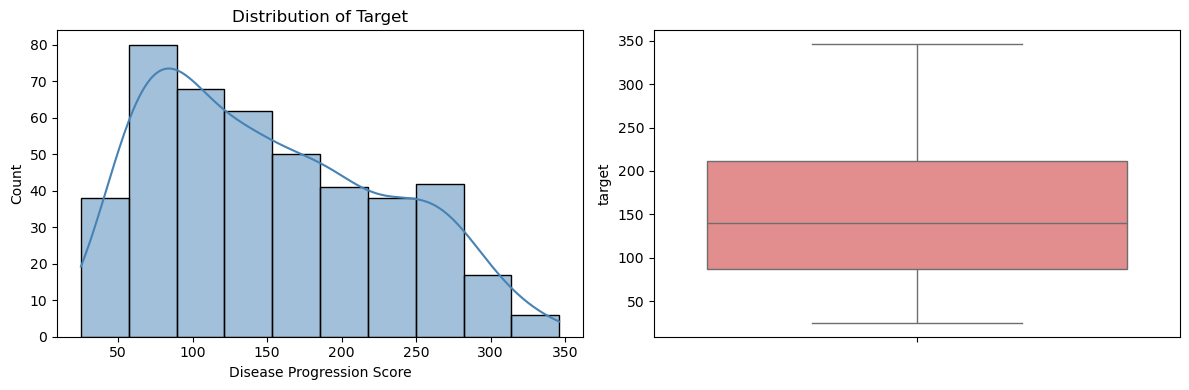

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram + kde
sns.histplot(df['target'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Target')
axes[0].set_xlabel('Disease Progression Score')

# Right: boxplot
sns.boxplot(df['target'], color='lightcoral')

plt.tight_layout()
plt.show()

In [ ]:
# SOLUTION
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['target'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Target')
axes[0].set_xlabel('Disease Progression Score')

sns.boxplot(y=df['target'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Target')
axes[1].set_ylabel('Disease Progression Score')

plt.tight_layout()
plt.show()

## A2 · Scatter Plot — Feature vs Target

- Create a figure with **2 subplots side by side**
- Left: scatter plot of `bmi` (x) vs `target` (y)
- Right: scatter plot of `bp` (x) vs `target` (y)
- Set `alpha=0.5` on each to handle overplotting
- Add axis labels and titles

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bmi vs target
# YOUR CODE HERE

# Right: bp vs target
# YOUR CODE HERE

plt.tight_layout()
plt.show()

In [ ]:
# SOLUTION
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=df, x='bmi', y='target', alpha=0.5, ax=axes[0])
axes[0].set_title('BMI vs Target')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Disease Progression')

sns.scatterplot(data=df, x='bp', y='target', alpha=0.5, ax=axes[1], color='darkorange')
axes[1].set_title('Blood Pressure vs Target')
axes[1].set_xlabel('Blood Pressure')
axes[1].set_ylabel('Disease Progression')

plt.tight_layout()
plt.show()

## A3 · Correlation Heatmap

- Compute the correlation matrix of the full `df` using `.corr()`
- Plot it as a heatmap using `sns.heatmap()`
- Use `annot=True`, `fmt='.2f'`, `cmap='coolwarm'`

In [ ]:
# YOUR CODE HERE


In [ ]:
# SOLUTION
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

---
# Part B — scikit-learn ML Workflow

## B1 · Train/Test Split

- Define `X` (all columns except `target`) and `y` (`target`)
- Split using `train_test_split` with `test_size=0.2` and `random_state=42`
- Print the shape of `X_train` and `X_test`

In [ ]:
# YOUR CODE HERE
X = ...
y = ...

X_train, X_test, y_train, y_test = ...

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

In [ ]:
# SOLUTION
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

## B2 · Linear Regression

- Fit a `LinearRegression` model on the training data
- Predict on `X_test`
- Print **MAE**, **RMSE**, and **R²**
- Plot predicted vs actual (scatter), with a red dashed diagonal line for perfect prediction

In [ ]:
# Fit & predict
# YOUR CODE HERE

# Metrics
# YOUR CODE HERE

# Plot
# YOUR CODE HERE


In [ ]:
# SOLUTION
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("── Linear Regression ──")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred_lr, alpha=0.5)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', label='Perfect prediction')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Linear Regression: Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.show()

## B3 · Decision Tree — Depth vs Performance

- Train a `DecisionTreeRegressor` with `max_depth=4`, print its metrics
- Then loop over `depths = [2, 3, 4, 5, 6, 8, 10, None]`, fit a tree for each, and record RMSE on the test set
- Plot RMSE vs depth — you should see it drop then flatten (or rise) as depth increases

In [ ]:
# Fit depth=4 and print metrics
# YOUR CODE HERE

# Loop over depths
depths = [2, 3, 4, 5, 6, 8, 10, None]
rmse_by_depth = []

# YOUR CODE HERE

# Plot
# YOUR CODE HERE


In [ ]:
# SOLUTION
dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("── Decision Tree (depth=4) ──")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_dt):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_dt):.4f}")

depths = [2, 3, 4, 5, 6, 8, 10, None]
rmse_by_depth = []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    rmse_by_depth.append(np.sqrt(mean_squared_error(y_test, m.predict(X_test))))

fig, ax = plt.subplots(figsize=(8, 4))
labels = [str(d) if d is not None else 'None' for d in depths]
ax.plot(labels, rmse_by_depth, marker='o', color='darkorange')
ax.set_title('Decision Tree: RMSE vs Max Depth')
ax.set_xlabel('max_depth')
ax.set_ylabel('RMSE')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## B4 · Random Forest + Feature Importance

- Train a `RandomForestRegressor` with `n_estimators=100` and `random_state=42`
- Print MAE, RMSE, R²
- Extract `rf.feature_importances_` and plot a horizontal bar chart, sorted by importance

In [ ]:
# Fit & metrics
# YOUR CODE HERE

# Feature importance plot
# YOUR CODE HERE


In [ ]:
# SOLUTION
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("── Random Forest ──")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Random Forest: Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## B5 · Model Comparison

- Build a summary DataFrame with columns `Model`, `MAE`, `RMSE`, `R2` — one row per model
- Print the table
- Plot a grouped bar chart comparing MAE and RMSE across all three models

In [ ]:
# YOUR CODE HERE


In [ ]:
# SOLUTION
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE':  [mean_absolute_error(y_test, p) for p in [y_pred_lr, y_pred_dt, y_pred_rf]],
    'RMSE': [np.sqrt(mean_squared_error(y_test, p)) for p in [y_pred_lr, y_pred_dt, y_pred_rf]],
    'R2':   [r2_score(y_test, p) for p in [y_pred_lr, y_pred_dt, y_pred_rf]]
}).round(3)

print(results.to_string(index=False))

x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, results['MAE'],  w, label='MAE',  color='steelblue')
ax.bar(x + w/2, results['RMSE'], w, label='RMSE', color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylabel('Error')
ax.set_title('Model Comparison: MAE and RMSE')
ax.legend()
plt.tight_layout()
plt.show()